In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

In [2]:
train_dir = "../data/raw/Training"
test_dir = "../data/raw/Testing"

In [4]:
# 🔥 IMPORTANT IMPORT (ADD THIS)
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 🔹 TRAIN DATA GENERATOR
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.3,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],  # 🔥 important
    shear_range=0.1               # 🔥 important
)

# 🔹 TEST DATA GENERATOR
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [5]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [7]:
# 🔥 IMPORTANT IMPORT
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 🔹 COMPUTE CLASS WEIGHTS
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


In [8]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# 🔥 IMPORTANT IMPORT
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 🔹 EARLY STOPPING
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 🔹 REDUCE LR
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

In [12]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.7550 - loss: 0.7358 - val_accuracy: 0.7937 - val_loss: 0.5323 - learning_rate: 0.0010
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8352 - loss: 0.4615 - val_accuracy: 0.8481 - val_loss: 0.4584 - learning_rate: 0.0010
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8627 - loss: 0.3759 - val_accuracy: 0.8650 - val_loss: 0.4687 - learning_rate: 0.0010
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8732 - loss: 0.3459 - val_accuracy: 0.8456 - val_loss: 0.5007 - learning_rate: 0.0010
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8813 - loss: 0.3089 - val_accuracy: 0.8806 - val_loss: 0.4089 - learning_rate: 3.0000e-04
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.8977 - loss: 0.2758 - val_accuracy: 0.8806 - val_loss: 0.3936 - learning_rate: 3.0000e-04
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.9023 - 

In [13]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-7),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history_fine = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.8939 - loss: 0.2691 - val_accuracy: 0.9006 - val_loss: 0.3512
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.9039 - loss: 0.2509 - val_accuracy: 0.8969 - val_loss: 0.3533
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.8943 - loss: 0.2689 - val_accuracy: 0.8956 - val_loss: 0.3550
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.8934 - loss: 0.2743 - val_accuracy: 0.8956 - val_loss: 0.3543
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.9014 - loss: 0.2645 - val_accuracy: 0.8963 - val_loss: 0.3546


In [16]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-7),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=test_data,
    epochs=2
)

Epoch 1/2
175/175 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.8991 - loss: 0.2696 - val_accuracy: 0.8975 - val_loss: 0.3516
Epoch 2/2
175/175 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9038 - loss: 0.2615 - val_accuracy: 0.8969 - val_loss: 0.3508


In [17]:
# Unfreeze more layers
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine2 = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.9034 - loss: 0.2474 - val_accuracy: 0.8975 - val_loss: 0.3473 - learning_rate: 1.0000e-05
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.9093 - loss: 0.2345 - val_accuracy: 0.9019 - val_loss: 0.3539 - learning_rate: 1.0000e-05
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.9162 - loss: 0.2246 - val_accuracy: 0.9000 - val_loss: 0.3589 - learning_rate: 3.0000e-06


In [18]:
# Evaluate model
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 744ms/step - accuracy: 0.8975 - loss: 0.3473
Test Accuracy: 0.8974999785423279


50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 685ms/step


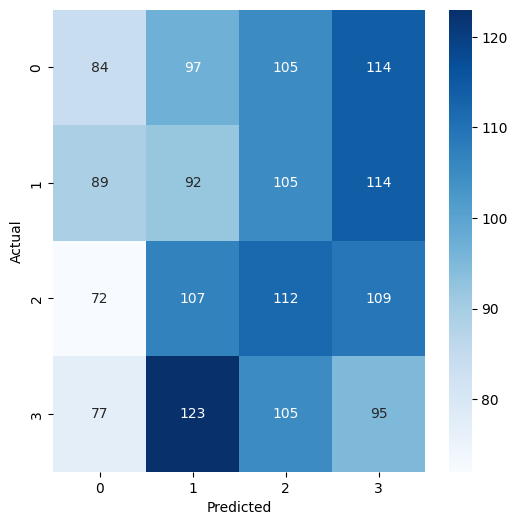

              precision    recall  f1-score   support

           0       0.26      0.21      0.23       400
           1       0.22      0.23      0.22       400
           2       0.26      0.28      0.27       400
           3       0.22      0.24      0.23       400

    accuracy                           0.24      1600
   macro avg       0.24      0.24      0.24      1600
weighted avg       0.24      0.24      0.24      1600



In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred_classes))

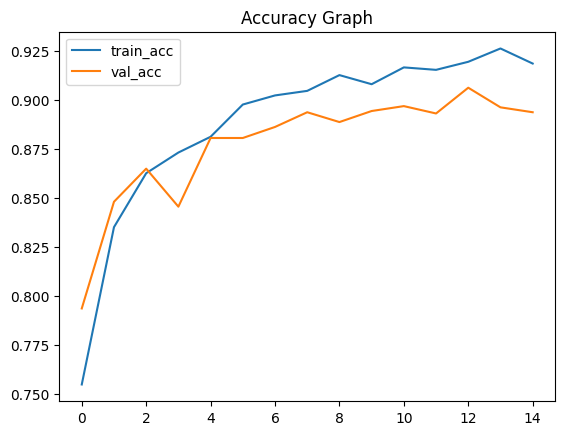

In [22]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [23]:
# 🔥 RECREATE TEST DATA (IMPORTANT FIX)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # 🔥 VERY IMPORTANT
)

Found 1600 images belonging to 4 classes.


In [24]:
import numpy as np

# Predictions
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_data.classes

50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 714ms/step


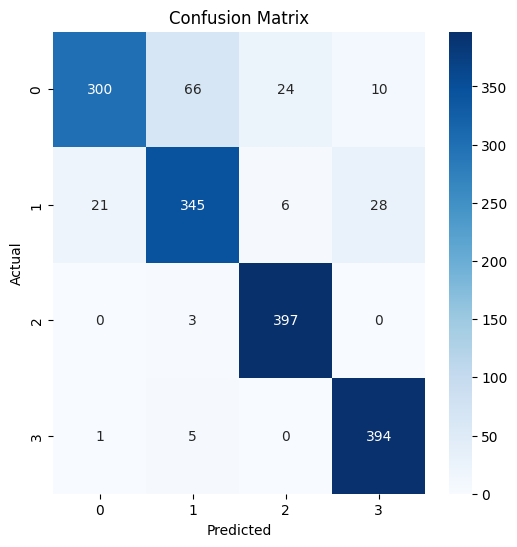

              precision    recall  f1-score   support

           0       0.93      0.75      0.83       400
           1       0.82      0.86      0.84       400
           2       0.93      0.99      0.96       400
           3       0.91      0.98      0.95       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred_classes))